<a href="https://colab.research.google.com/github/Shahrizodaaa/german-credit-svm/blob/main/German_Credit_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("/content/german_credit_data (1).csv")

This loads the **German Credit** CSV file into a pandas DataFrame called df, so we can start working with the data in Python.


In [2]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


df.head() shows the first 5 rows of the dataset, so we can quickly check what the columns and values look like.

In [3]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

df.columns prints the names of all columns in the dataset, so we know exactly what information we have.

In [4]:
df.info()          # har bir ustunning turi (raqam/matn) va nechta bo'sh joy borligini ko'rsatadi
df.describe()      # raqamli ustunlar uchun statistika: o'rtacha, min, max, standart chetlanish
df.shape           # nechta qator va ustun borligi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


(1000, 11)

1. df.info() shows the data type of each column and how many missing values it has.
2. df.describe() gives basic statistics (mean, min, max) for numeric columns.
3. df.shape tells us how many rows and columns the dataset has.

In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


df.isnull().sum() counts how many **missing (empty) values** are in each column, so we know which columns need cleaning.

In [6]:
df["Risk"].value_counts()

,count
Risk,
good,700
bad,300


df["Risk"].value_counts() counts how many **"good"** and **"bad"** customers there are, so we can see if the classes are balanced or not.

In [7]:
df = df.drop(columns=["Unnamed: 0"])

Unnamed: 0 is just a leftover row index from saving the CSV file — it has no real meaning, so we drop it.

In [8]:
df["Saving accounts"] = df["Saving accounts"].fillna("none")
df["Checking account"] = df["Checking account"].fillna("none")

Missing values in "Saving accounts" and "Checking account" likely mean the customer simply doesn't have that type of account. We fill them with the label "none" instead of leaving them empty.

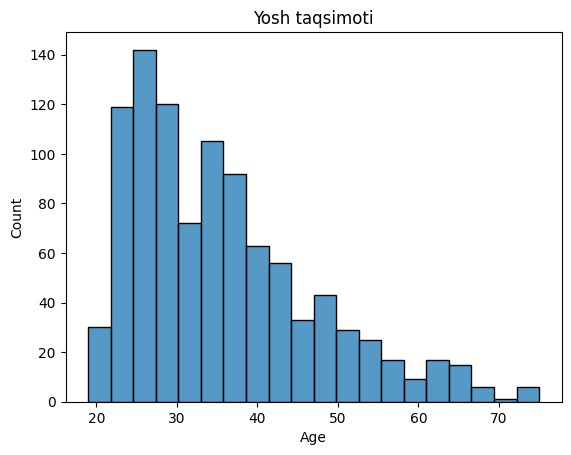

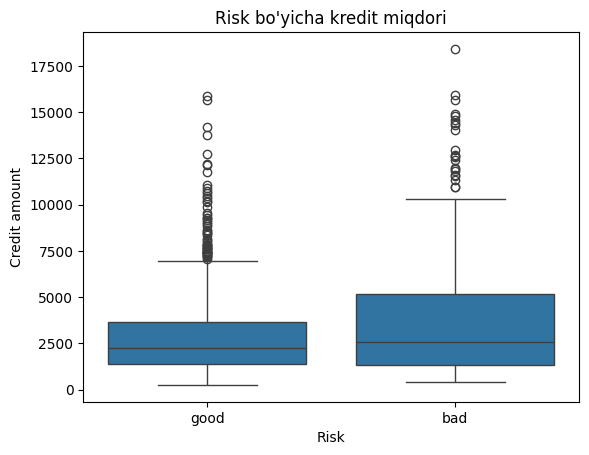

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Yosh taqsimoti
sns.histplot(df["Age"], bins=20)
plt.title("Yosh taqsimoti")
plt.show()

# 2. Risk bo'yicha Credit amount taqsimoti
sns.boxplot(x="Risk", y="Credit amount", data=df)
plt.title("Risk bo'yicha kredit miqdori")
plt.show()

The histogram shows how customer ages are distributed. The boxplot compares credit amounts between "good" and "bad" risk customers, and helps us visually spot outliers (unusually high values).

In [10]:
Q1 = df["Credit amount"].quantile(0.25)
Q3 = df["Credit amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Credit amount"] < lower_bound) | (df["Credit amount"] > upper_bound)]
print("Outlierlar soni:", outliers.shape[0])
print("Chegaralar:", lower_bound, "-", upper_bound)

Outlierlar soni: 72
Chegaralar: -2544.625 - 7882.375


We calculate the **Interquartile Range (IQR)** for **"Credit amount"** and use it to find values that are unusually high or low (outliers). This tells us how many extreme values exist in the data.

In [11]:
# Sex va Risk - ikki qiymatli, Label Encoding mos
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Risk"] = df["Risk"].map({"good": 0, "bad": 1})

# Saving accounts va Checking account - tartibli (none < little < moderate < rich)
saving_order = {"none": 0, "little": 1, "moderate": 2, "quite rich": 3, "rich": 4}
df["Saving accounts"] = df["Saving accounts"].map(saving_order)

checking_order = {"none": 0, "little": 1, "moderate": 2, "rich": 3}
df["Checking account"] = df["Checking account"].map(checking_order)

# Housing va Purpose - tartibsiz, One-Hot Encoding
df = pd.get_dummies(df, columns=["Housing", "Purpose"], drop_first=True)

Machine learning models need numbers, not text. "Sex" and "Risk" are turned into 0/1 (Label Encoding). "Saving accounts" and "Checking account" are turned into ordered numbers (0=none, 1=little, etc.) because they have a natural order. "Housing" and "Purpose" are turned into separate 0/1 columns (One-Hot Encoding) because they have no natural order.

In [12]:
df["Checking account"].unique()

array([1, 2, 0, 3])

In [13]:
df["Saving accounts"].unique()

array([0, 1, 3, 4, 2])

.unique() shows all the distinct values now present in "Checking account" and "Saving accounts", confirming the encoding mapped everything correctly with no missing (NaN) values.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Age                          1000 non-null   int64
 1   Sex                          1000 non-null   int64
 2   Job                          1000 non-null   int64
 3   Saving accounts              1000 non-null   int64
 4   Checking account             1000 non-null   int64
 5   Credit amount                1000 non-null   int64
 6   Duration                     1000 non-null   int64
 7   Risk                         1000 non-null   int64
 8   Housing_own                  1000 non-null   bool 
 9   Housing_rent                 1000 non-null   bool 
 10  Purpose_car                  1000 non-null   bool 
 11  Purpose_domestic appliances  1000 non-null   bool 
 12  Purpose_education            1000 non-null   bool 
 13  Purpose_furniture/equipment  1000 non-null   bool

df.info() is run again to make sure every column is now a number (int64 or bool), which means the data is ready for a machine learning model.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Risk"])   # Risk'dan tashqari hamma narsa - feature'lar
y = df["Risk"]                  # target - bashorat qilinadigan narsa

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

We separate the target column ("Risk") from the rest of the features, then split the data into **80% for training** the model and **20% for testing** it. stratify=y keeps the same good/bad ratio in both parts.

In [16]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**RobustScaler** puts all numeric columns on a similar scale, which **SVM** needs to work properly. It's chosen over StandardScaler because it handles outliers better. We fit it only on the training data to avoid data leakage.

In [17]:
X_train_scaled.shape

(800, 16)

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

model = SVC(class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.71      0.77       140
           1       0.50      0.67      0.57        60

    accuracy                           0.70       200
   macro avg       0.67      0.69      0.67       200
weighted avg       0.73      0.70      0.71       200

[[100  40]
 [ 20  40]]


We train a **Support Vector Machine (SVC)** with class_weight="balanced" to handle the imbalance between **good/bad customers**, then test it and print performance metrics (precision, recall, F1-score) and the confusion matrix.

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    SVC(class_weight="balanced", random_state=42),
    param_grid,
    cv=5,                # 5 marta turli bo'laklarga bo'lib tekshiradi
    scoring="f1",        # accuracy o'rniga f1 - imbalance uchun to'g'riroq mezon
    n_jobs=-1             # barcha protsessor yadrolarini ishlatadi, tezroq bo'ladi
)

grid.fit(X_train_scaled, y_train)

print("Eng yaxshi parametrlar:", grid.best_params_)
print("Eng yaxshi F1 (train, cross-val):", grid.best_score_)

Eng yaxshi parametrlar: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Eng yaxshi F1 (train, cross-val): 0.5569198300341609


This automatically tries different combinations of **SVM settings** (C, kernel, gamma) and uses 5-fold cross-validation to find which combination gives the **best F1-score**.

In [21]:
best_model = grid.best_estimator_   # eng yaxshi parametrlar bilan o'rgatilgan model

y_pred_best = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.85      0.71      0.77       140
           1       0.51      0.70      0.59        60

    accuracy                           0.70       200
   macro avg       0.68      0.70      0.68       200
weighted avg       0.74      0.70      0.72       200

[[99 41]
 [18 42]]


We take the best model found by **GridSearchCV** and evaluate it on the test data, comparing its performance to the earlier basic model.